#### Imports

In [1]:
import importlib
import matplotlib.pyplot as plt
import numpy as np
import random
from pathlib import Path
import pandas as pd
import time

import torch
from torchinfo import summary as info_summary
import pickle

import globals
import utils
import nn_dataset
import nn_models

np.set_printoptions(precision=4, suppress=True, linewidth=np.inf, threshold=np.inf)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Current device:", device)

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

Current device: cuda


In [2]:
importlib.reload(globals)
importlib.reload(utils)
importlib.reload(nn_dataset)
importlib.reload(nn_models)

<module 'nn_models' from 'c:\\Users\\Matteo\\Desktop\\Scuola\\MastersThesis\\Masters_Thesis\\nn_models.py'>

In [3]:
param_names, function_names = utils.inspect_metadata(globals.CURRENT_TRAIN_FILE)

Keys in train_file: ['I0', 'LUTdata', 'LUTheader', 'dynamic', 'static', 'wvl']

Attributes in LUTheader (inputs):
  varnames: O3STR,H2OSTR,VIS,G,ASTMX,SSA,PARM2,OBSZEN,PARM1

Attributes in train_file (outputs):
  RTMname: MODTRAN6
  inputmode: Latin hypercube
  lut_package_date: 10-Apr-2025
  opmode: Transfer Functions
  outnames: Lp0,Edir0,Edif0,S,tdir,tdif
  sensor: Empty(dtype=dtype('O'))

LUTheader shape: (500, 9)
LUTdata shape: (500, 25230)
wvl shape: (1, 4205)


In [4]:
X, Y, wavelengths = utils.load_train_h5(globals.CURRENT_TRAIN_FILE)
wavelengths = wavelengths.squeeze()
Y_resh = Y.reshape(-1, Y.shape[1] // len(wavelengths), len(wavelengths))

X_tr, X_val, X_test, Y_tr, Y_val, Y_test = utils.train_val_test_split(X, Y_resh, wavelengths, verbose=True)

X shape: (500, 9)
Y shape: (500, 6, 4205)
wavelengths shape: (4205,)

X_tr shape: (400, 9)
X_val shape: (50, 9)
X_test shape: (50, 9)

Y_tr shape: (400, 6, 4205)
Y_val shape: (50, 6, 4205)
Y_test shape: (50, 6, 4205)


#### Neural Network Pipeline

<ol>
    <li><b>Model and Dataset Definition</b>: Encoder-Decoder architectures.</li>
    <li><b>Training/Validation</b>: train loop with validation to choose the best model.</li>
    <li><b>External Testing</b> of the best selected model.</li>
</ol>

In [5]:
importlib.reload(nn_models)

# quick model test
model = nn_models.EmulatorSet5(encoder_type="single").to(device)
model.eval()

# dummy input: (batch_size, 9)
X_tr_tensor = torch.randn(400, 9, dtype=torch.float32).to(device)
print("Input shape:", X_tr_tensor.shape)

with torch.no_grad():
    y_pred, features = model(X_tr_tensor)

# y is a tensor of shape (N, 6, 4205)
print("Output shape:", y_pred.shape)

info_summary(model, input_size=(1, 9))

Input shape: torch.Size([400, 9])
Output shape: torch.Size([400, 6, 4205])


Layer (type:depth-idx)                             Output Shape              Param #
EmulatorSet5                                       [1, 6, 4205]              --
├─Encoder5: 1-1                                    [1, 128]                  --
│    └─ResidualFCBlock: 2-1                        [1, 64]                   --
│    │    └─Linear: 3-1                            [1, 64]                   640
│    │    └─Linear: 3-2                            [1, 64]                   576
│    │    └─SiLU: 3-3                              [1, 64]                   --
│    └─ResidualFCBlock: 2-2                        [1, 128]                  --
│    │    └─Linear: 3-4                            [1, 128]                  8,320
│    │    └─Linear: 3-5                            [1, 128]                  8,192
│    │    └─SiLU: 3-6                              [1, 128]                  --
│    └─ResidualFCBlock: 2-3                        [1, 128]                  --
│    │    └─Linear: 3-7    

Investigate scaled datasets.

In [6]:
# scaled outputs
y_scalers, Y_tr_scaled, Y_val_scaled = utils.scale_output_data(Y_tr, Y_val, scale_type="minmax")

print("Train scaled min:", Y_tr_scaled.min())
print("Val scaled min:", Y_val_scaled.min())

print(np.sum(Y_tr_scaled == 0))
print(np.sum(Y_val_scaled == 0))

---------- Scaling output data using minmax scaling... ----------
---------- Output data scaling completed. ----------

Train scaled min: 0.0
Val scaled min: -0.16481781
103253
9799


Using MRE as the loss function in this scenario would not be desirable, as the training loss would explode to very high values due to the high amount of training values near zero. Scaled or reduced data has many values that are zero or near zero, which would make the MRE explode. Using a wavelength mask would exclude deep absorption bands, but the MRE would still be calculated on the scaled and reduced data, which would not solve the exploding problem. MRE calculated on the restored data could be used as loss, but it would not be a meaningful objective, as it would be calculated on data that is fundamentally different from what the model actually sees.

In [7]:
config = utils.nn_prepare_all_experiments(X_tr, X_val, X_test, Y_tr, Y_val, Y_test)

---------- Applying PCA with n_components=10 to each function separately... ----------
  Regular PCA used, displaying results:
  Function 1: Explained variance = 1.0000
  Number of components retained: 10

  Function 2: Explained variance = 1.0000
  Number of components retained: 10

  Function 3: Explained variance = 1.0000
  Number of components retained: 10

  Function 4: Explained variance = 0.9999
  Number of components retained: 10

  Function 5: Explained variance = 1.0000
  Number of components retained: 10

  Function 6: Explained variance = 1.0000
  Number of components retained: 10

  Total explained variance = 5.9999
---------- PCA application completed. ----------


── Preparing [minmax] ──────────────────────────────
---------- Scaling input data using minmax scaling... ----------
---------- Input data scaling completed. ----------

---------- Scaling output data using minmax scaling... ----------
---------- Output data scaling completed. ----------

---------- Scaling ou

In [8]:
# ============================== !!CRITICAL CELL!! ==============================

summary, last_model, last_history = utils.nn_run_all_experiments(config, device, wavelengths)

Total experiments to run: 1

  EXPERIMENT: EmulatorSet5_single_minmax_500


  E001 | train loss 0.14970  mre 0.15174  mae 28.99553 | val loss 0.07731  mre 0.07628  mae 12.23050
  --> best val MRE — weights saved


  E002 | train loss 0.06112  mre 0.06265  mae 10.18944 | val loss 0.04751  mre 0.05056  mae 6.55917
  --> best val MRE — weights saved


  E003 | train loss 0.04606  mre 0.04778  mae 6.88103 | val loss 0.04017  mre 0.04249  mae 5.62347
  --> best val MRE — weights saved


  E004 | train loss 0.03616  mre 0.03699  mae 4.95582 | val loss 0.03189  mre 0.03381  mae 3.74338
  --> best val MRE — weights saved


...

  E096 | train loss 0.00363  mre 0.00295  mae 0.33866 | val loss 0.00429  mre 0.00420  mae 0.42078
  --> no improvement (5/25)


  E097 | train loss 0.00368  mre 0.00302  mae 0.34205 | val loss 0.00417  mre 0.00404  mae 0.39397
  --> no improvement (6/25)


  E098 | train loss 0.00344  mre 0.00274  mae 0.30307 | val loss 0.00408  mre 0.00394  mae 0.39867
  --> best val MRE — weights saved


  E099 | train loss 0.00342  mre 0.00272  mae 0.30071 | val loss 0.00406  mre 0.00391  mae 0.38480
  --> best val MRE — weights saved


  E100 | train loss 0.00341  mre 0.00271  mae 0.29783 | val loss 0.00405  mre 0.00393  mae 0.38609
  --> no improvement (1/25)
  Saved results for EmulatorSet5_single_minmax_500


===== EXPERIMENT SUMMARY (sorted by val MRE) =====
                 experiment_id  best_val_mre  best_val_mae  best_epoch   fit_time
EmulatorSet5_single_minmax_500      0.003909      0.384799          99 413.241054


In [18]:
summary

,experiment_id,model,encoder,scale_type,dataset_size,fit_time,best_epoch,best_train_loss,best_val_loss,best_train_mre,best_val_mre,best_train_mae,best_val_mae
8,EmulatorSet3_single_minmax_10000,EmulatorSet3,single,minmax,10000,793.746402,96,0.002185,0.002164,0.000950,0.000969,0.111073,0.111109
13,EmulatorSet4_single_standard_10000,EmulatorSet4,single,standard,10000,605.449314,100,0.019993,0.019780,0.001033,0.001071,0.129294,0.132132
10,EmulatorSet3_multi_minmax_10000,EmulatorSet3,multi,minmax,10000,805.632896,98,0.002316,0.002294,0.001094,0.001115,0.121058,0.119053
5,EmulatorSet2_single_standard_10000,EmulatorSet2,single,standard,10000,580.186641,98,0.019770,0.019546,0.001122,0.001143,0.136631,0.138685
11,EmulatorSet3_multi_standard_10000,EmulatorSet3,multi,standard,10000,804.360499,96,0.017508,0.017574,0.001161,0.001238,0.144344,0.153114
15,EmulatorSet4_multi_standard_10000,EmulatorSet4,multi,standard,10000,632.977189,94,0.020753,0.020484,0.001227,0.001273,0.155539,0.156810
9,EmulatorSet3_single_standard_10000,EmulatorSet3,single,standard,10000,796.381909,97,0.018637,0.018710,0.001233,0.001311,0.151798,0.161039
14,EmulatorSet4_multi_minmax_10000,EmulatorSet4,multi,minmax,10000,632.440834,79,0.002761,0.002695,0.001456,0.001474,0.163270,0.159235
7,EmulatorSet2_multi_standard_10000,EmulatorSet2,multi,standard,10000,607.487307,100,0.021944,0.021594,0.001495,0.001525,0.181377,0.183825
12,EmulatorSet4_single_minmax_10000,EmulatorSet4,single,minmax,10000,606.511677,97,0.002797,0.002743,0.001511,0.001547,0.162551,0.159867


#### Analysis of Validation Results

Average Fit Time by Dataset Size
 dataset_size  avg_fit_time
          500    111.891453
         2000    195.761592
        10000    728.191658

Average Best Val MRE by Dataset Size & Model
 dataset_size        model  avg_best_val_mre
          500 EmulatorSet1          0.007801
          500 EmulatorSet2          0.005822
          500 EmulatorSet3          0.007190
          500 EmulatorSet4          0.005671
         2000 EmulatorSet1          0.006230
         2000 EmulatorSet2          0.002889
         2000 EmulatorSet3          0.002675
         2000 EmulatorSet4          0.002516
        10000 EmulatorSet1          0.004820
        10000 EmulatorSet2          0.001686
        10000 EmulatorSet3          0.001158
        10000 EmulatorSet4          0.001341

Average Best Val MAE by Dataset Size & Model
 dataset_size        model  avg_best_val_mae
          500 EmulatorSet1          0.810456
          500 EmulatorSet2          0.660718
          500 EmulatorSet3          0.82942

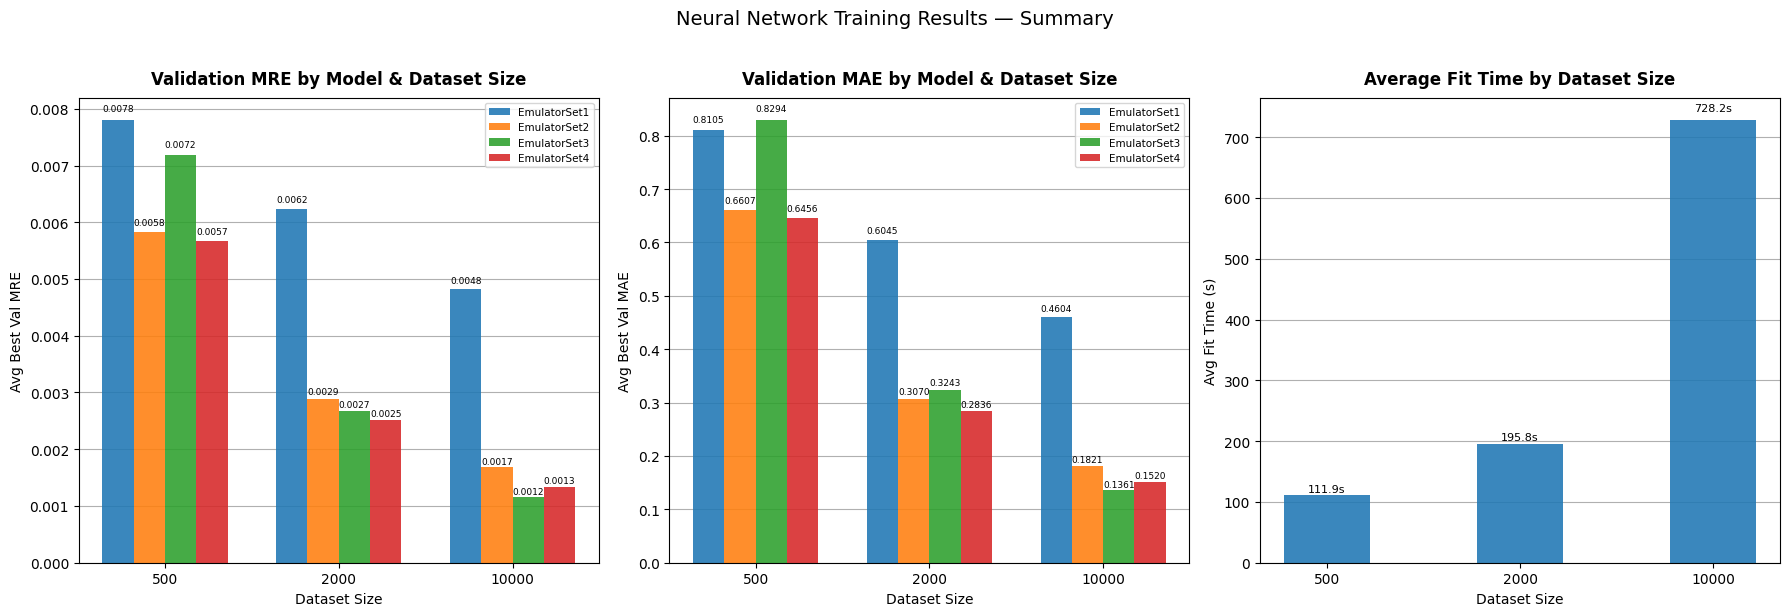


Figure saved to nn_saves/validation_results/nn_val_results_analysis.png


In [39]:
# results csv analysis
results_df = pd.read_csv("nn_saves/validation_results/nn_val_results.csv")
utils.show_fit_val_summary(results_df, save_path="nn_saves/validation_results/nn_val_results_analysis.png")

In [40]:
utils.show_top_results(results_df, top_n=5)


Top 5 Results by Best Validation MRE:
                     experiment_id        model encoder scale_type  dataset_size   fit_time  best_epoch  best_train_loss  best_val_loss  best_train_mre  best_val_mre  best_train_mae  best_val_mae
  EmulatorSet3_single_minmax_10000 EmulatorSet3  single     minmax         10000 793.746402          96         0.002185       0.002164        0.000950      0.000969        0.111073      0.111109
EmulatorSet4_single_standard_10000 EmulatorSet4  single   standard         10000 605.449314         100         0.019993       0.019780        0.001033      0.001071        0.129294      0.132132
   EmulatorSet3_multi_minmax_10000 EmulatorSet3   multi     minmax         10000 805.632896          98         0.002316       0.002294        0.001094      0.001115        0.121058      0.119053
EmulatorSet2_single_standard_10000 EmulatorSet2  single   standard         10000 580.186641          98         0.019770       0.019546        0.001122      0.001143        0.13

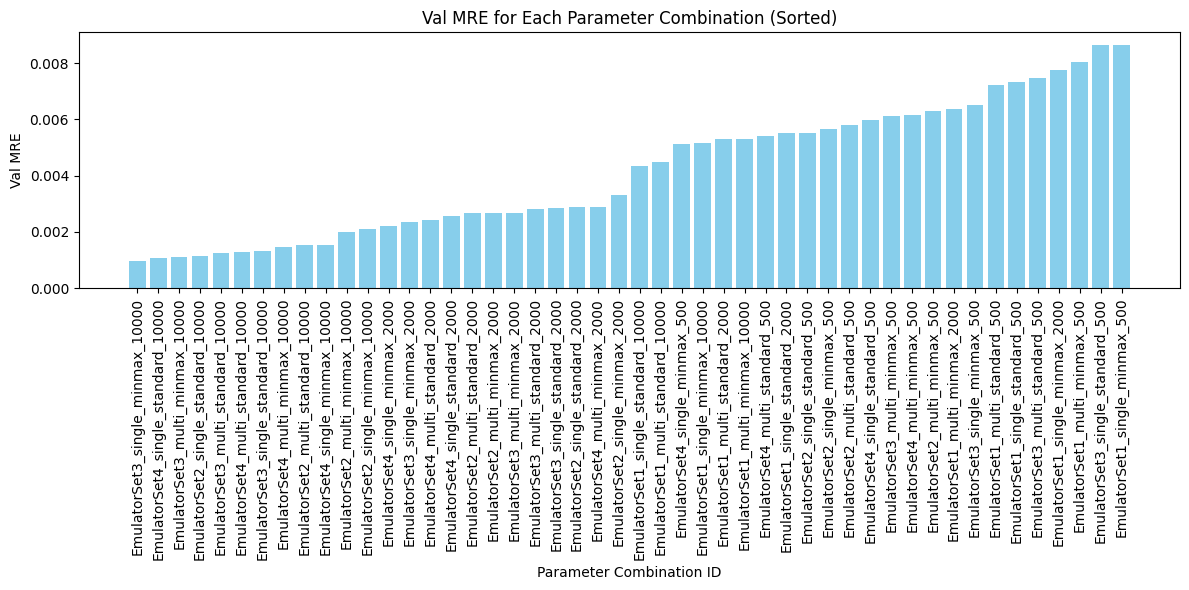


Bar plot saved to nn_saves/validation_results/nn_val_results_barplot.png


In [41]:
utils.show_barplot_results(results_df, save_path="nn_saves/validation_results/nn_val_results_barplot.png")

In [42]:
# chosen model row load
# chosen_model = results_df.loc[results_df["best_val_mre"].idxmin()]
chosen_model = results_df.loc[results_df["experiment_id"] == "EmulatorSet1_single_standard_10000"].iloc[0]
print(chosen_model)

experiment_id      EmulatorSet1_single_standard_10000
model                                    EmulatorSet1
encoder                                        single
scale_type                                   standard
dataset_size                                    10000
fit_time                                   921.296913
best_epoch                                        100
best_train_loss                              0.027664
best_val_loss                                0.027324
best_train_mre                               0.007093
best_val_mre                                  0.00433
best_train_mae                               0.395645
best_val_mae                                 0.387854
Name: 33, dtype: object


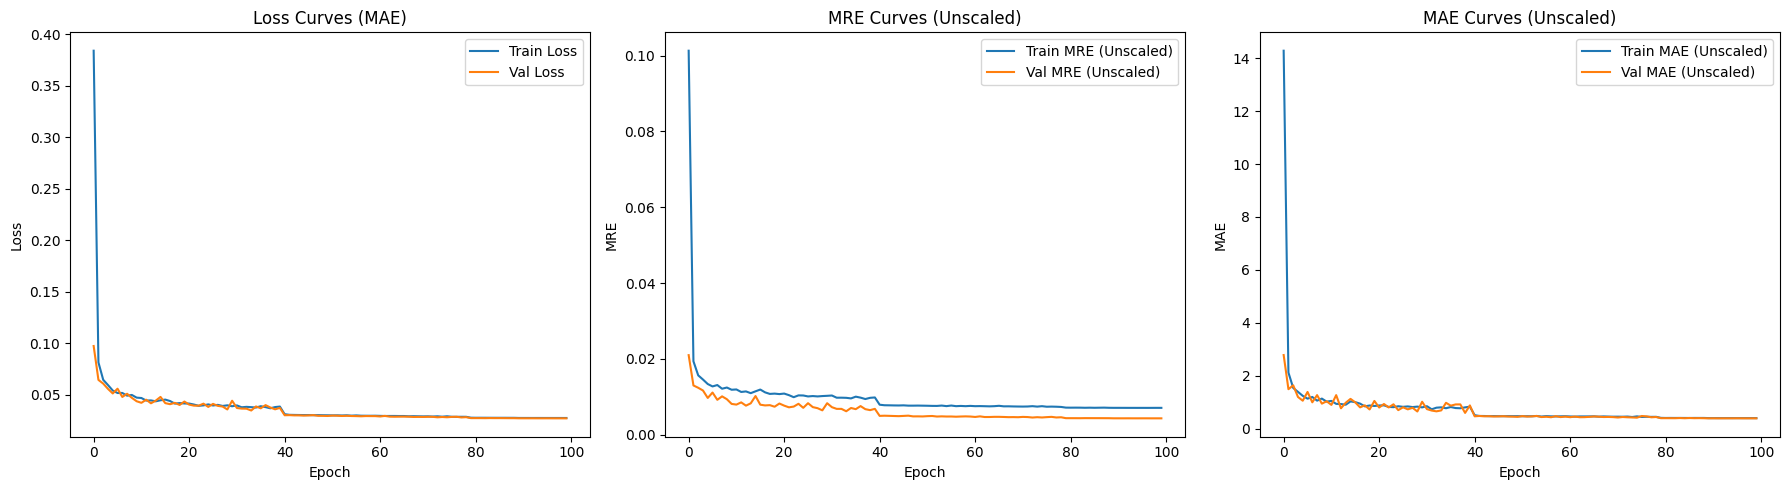

In [43]:
# history load
with open(f"nn_saves/model_saves/{chosen_model['experiment_id']}_history.pkl", "rb") as f:
    history = pickle.load(f)

# history plotting
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.title("Loss Curves (MAE)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(history["train_mre"], label="Train MRE (Unscaled)")
plt.plot(history["val_mre"], label="Val MRE (Unscaled)")
plt.title("MRE Curves (Unscaled)")
plt.xlabel("Epoch")
plt.ylabel("MRE")
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(history["train_mae"], label="Train MAE (Unscaled)")
plt.plot(history["val_mae"], label="Val MAE (Unscaled)")
plt.title("MAE Curves (Unscaled)")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()

plt.tight_layout()
plt.show()

#### External Testing

For both MRE and MAE:
<ul>
    <li>Global average metric.</li>
    <li>Metric for each function.</li>
    <li>Metric for each wavelength.</li>
    <li>Metric for each function and for each wavelength.</li>
</ul>

In [ ]:
def test_model(chosen_model):
    # load model
    model = utils.ARCHITECTURES[chosen_model["model"]](encoder_type=chosen_model["encoder"]).to(device)
    model.load_state_dict(torch.load(f"nn_saves/model_saves/{chosen_model['experiment_id']}.pth", map_location=device))

    if chosen_model["model"] in utils.FULL_DS_MODELS:
        # test_ds = config["test_ds_scaled"][chosen_model["scale_type"]]
        y_scalers = config["y_scalers"][chosen_model["scale_type"]]
        pca_list = None
    else:
        # test_ds = config["test_ds_reduced_scaled"][chosen_model["scale_type"]]
        y_scalers = config["y_scalers_reduced"][chosen_model["scale_type"]]
        pca_list = config["pca_lists"][chosen_model["scale_type"]]

    # predict on test set for other metrics and visualization
    X_test_tensor = torch.tensor(
        config["x_scalers"][chosen_model["scale_type"]].transform(X_test),
        dtype=torch.float32
    ).to(device)

    is_scaled  = y_scalers is not None
    is_reduced = pca_list  is not None
    model.eval()
    with torch.no_grad():
        y_pred_test = model(X_test_tensor)
        if is_scaled or is_reduced:
            y_pred_og_shape = torch.zeros((y_pred_test.size(0), globals.N_FUNCTIONS, len(wavelengths)), device=y_pred_test.device)
            for i in range(globals.N_FUNCTIONS):
                y_pred_restored = y_pred_test[:, i, :].cpu().detach().numpy()
                if is_scaled:
                    y_pred_restored = y_scalers[i].inverse_transform(y_pred_restored)
                if is_reduced:
                    y_pred_restored = pca_list[i].inverse_transform(y_pred_restored)
                y_pred_og_shape[:, i, :] = torch.from_numpy(y_pred_restored).to(y_pred_test.device)
            y_pred_test = y_pred_og_shape

    y_pred_test_np = y_pred_test.cpu().numpy()

    return y_pred_test_np

--------------------------------------------------
Experiment ID: EmulatorSet3_single_minmax_10000
Model: EmulatorSet3
Encoder: single
Scale Type: minmax
Dataset Size: 10000
Fit Time: 793.75 seconds
Best Validation MRE: 0.0010
Best Validation MAE: 0.1111
--------------------------------------------------
Testing MRE: 0.0017323158
Path Radiance MRE: 0.0034
Direct Solar Irradiance MRE: 0.0008
Diffuse Solar Irradiance MRE: 0.0025
Spherical Albedo MRE: 0.0019
Direct Transmittance MRE: 0.0003
Diffuse Transmittance MRE: 0.0014


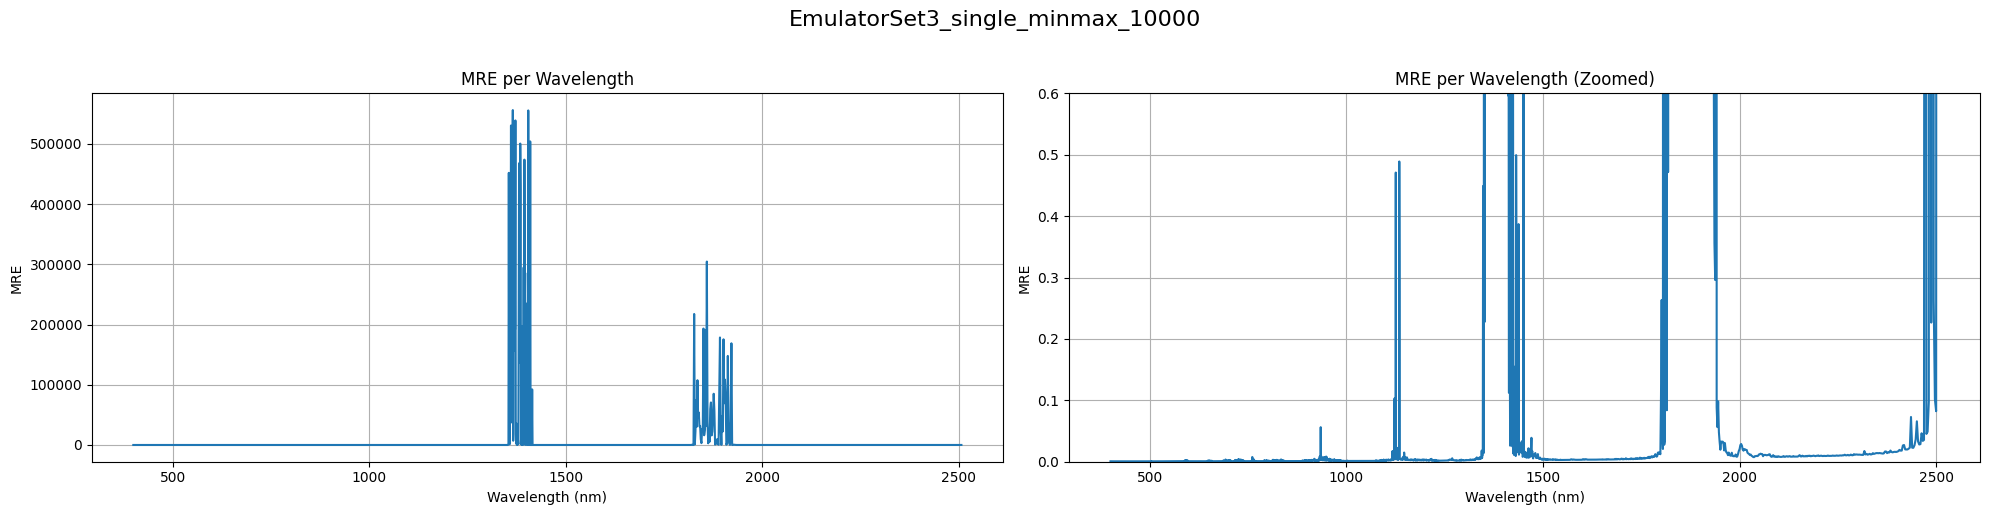

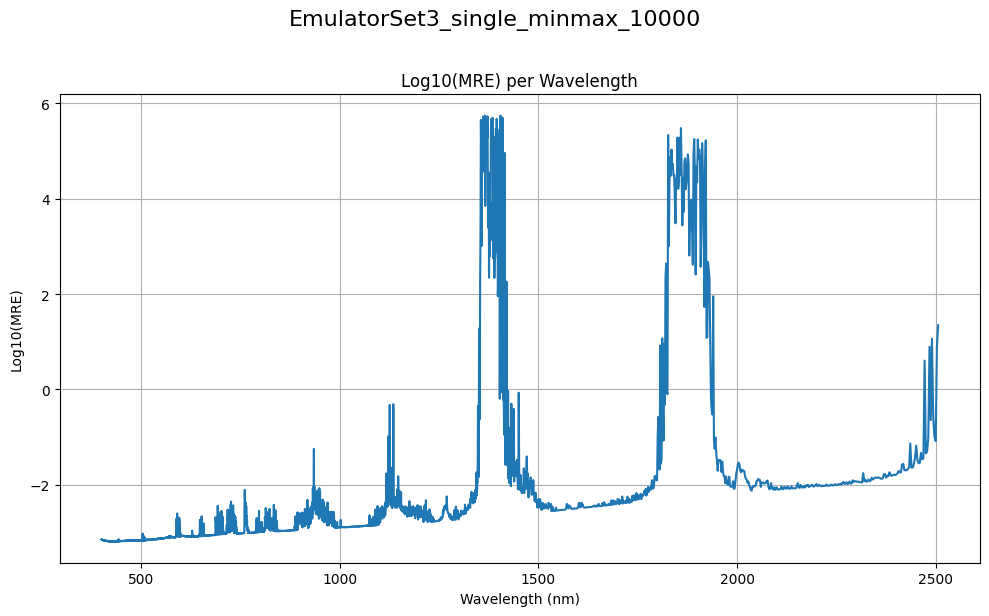

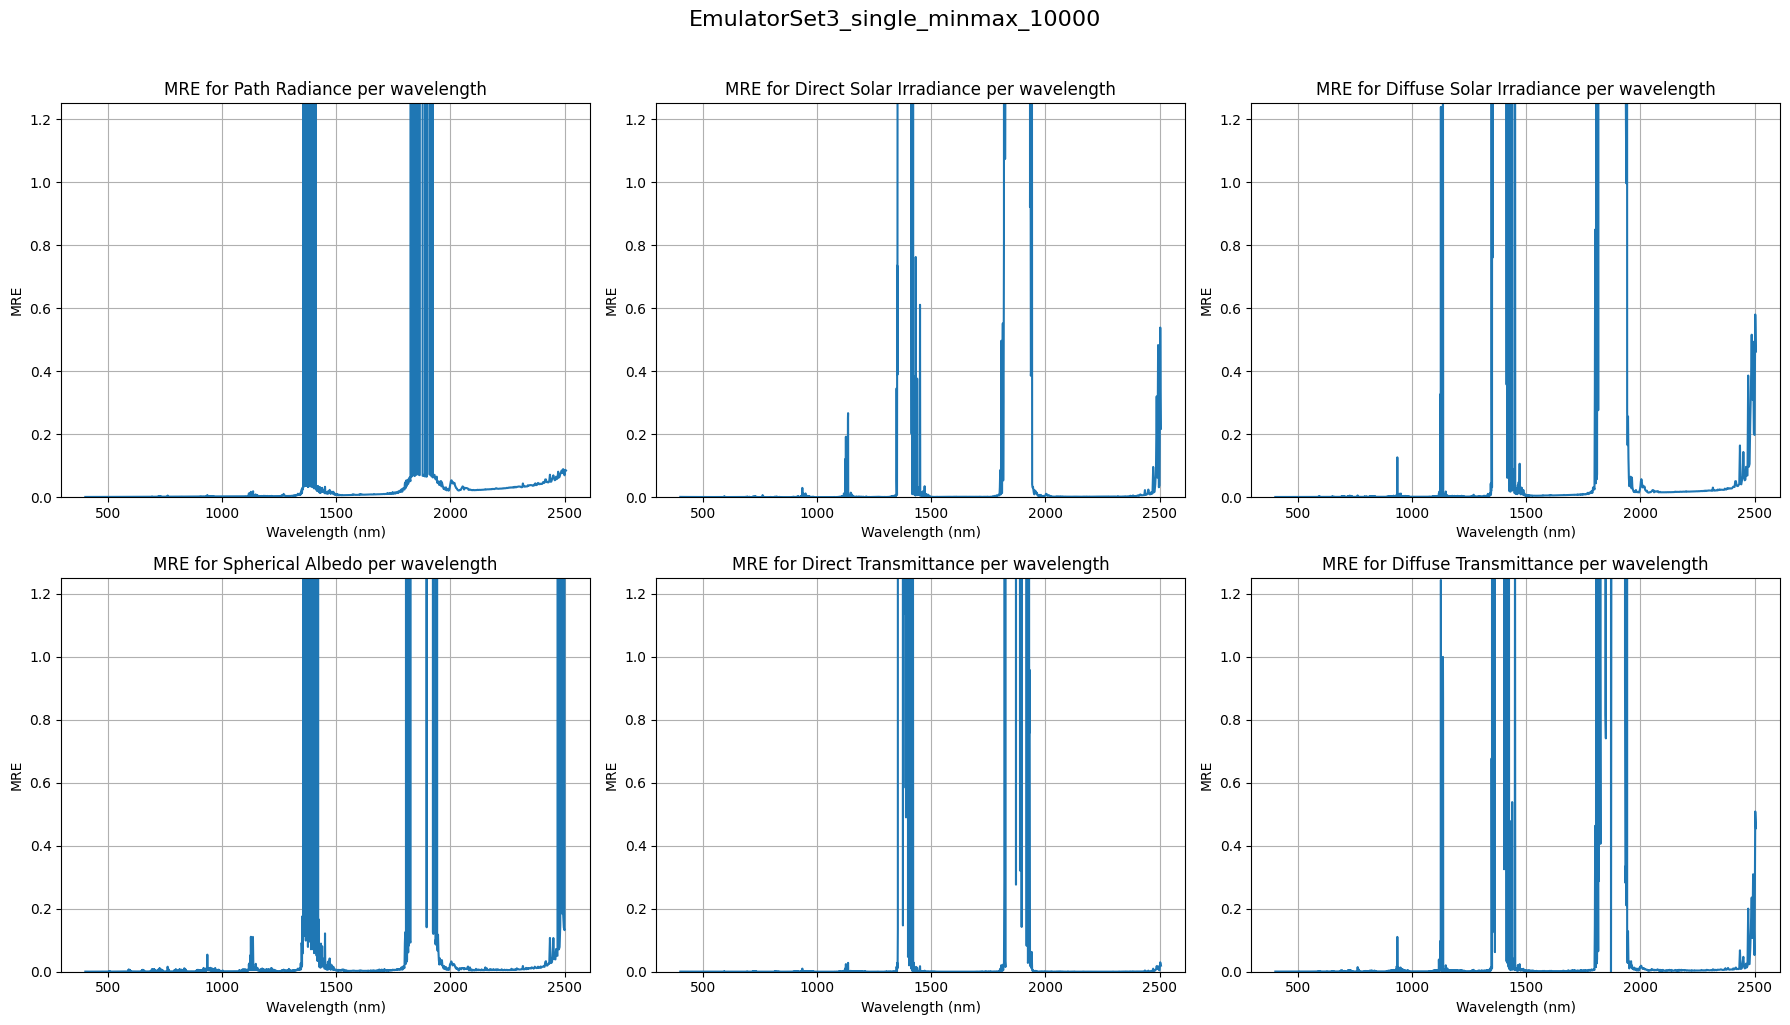

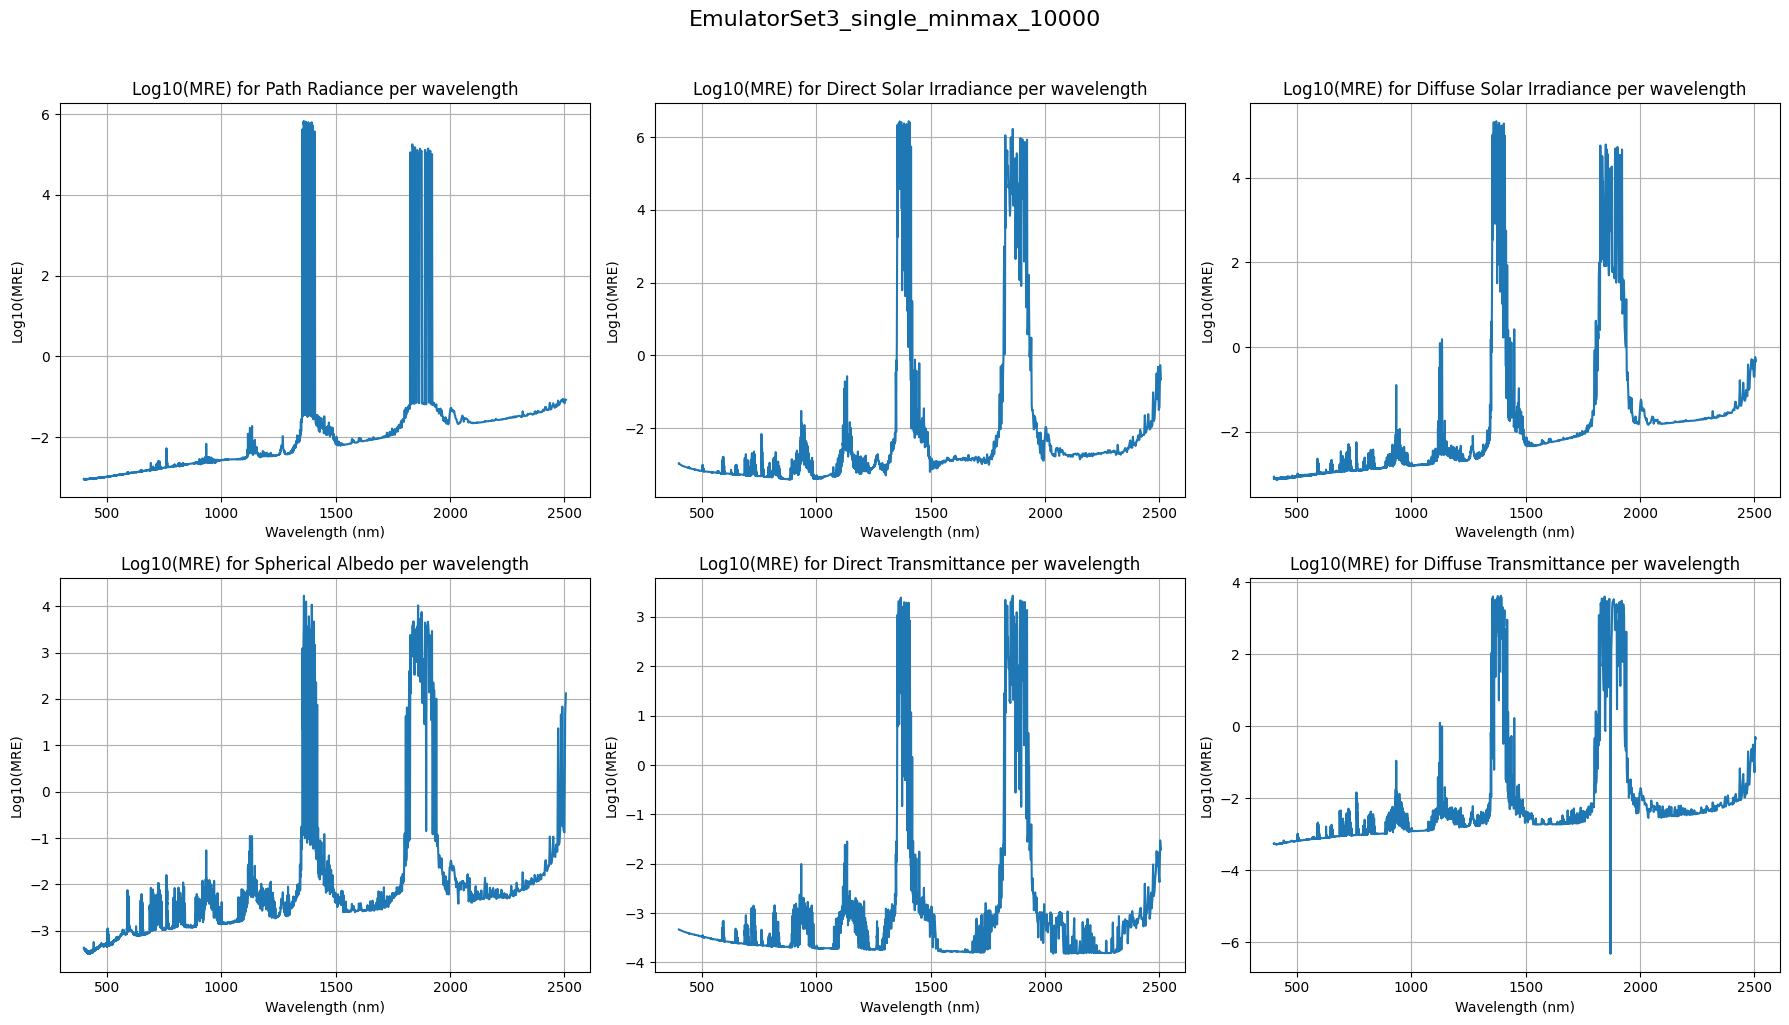

Testing MAE: 0.13308044
Path Radiance MAE: 0.0238
Direct Solar Irradiance MAE: 0.5219
Diffuse Solar Irradiance MAE: 0.2504
Spherical Albedo MAE: 0.0001
Direct Transmittance MAE: 0.0002
Diffuse Transmittance MAE: 0.0002


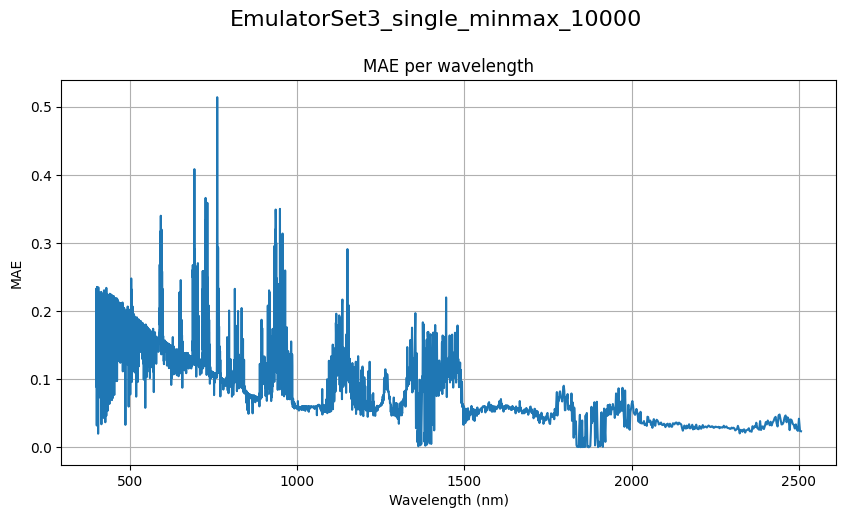

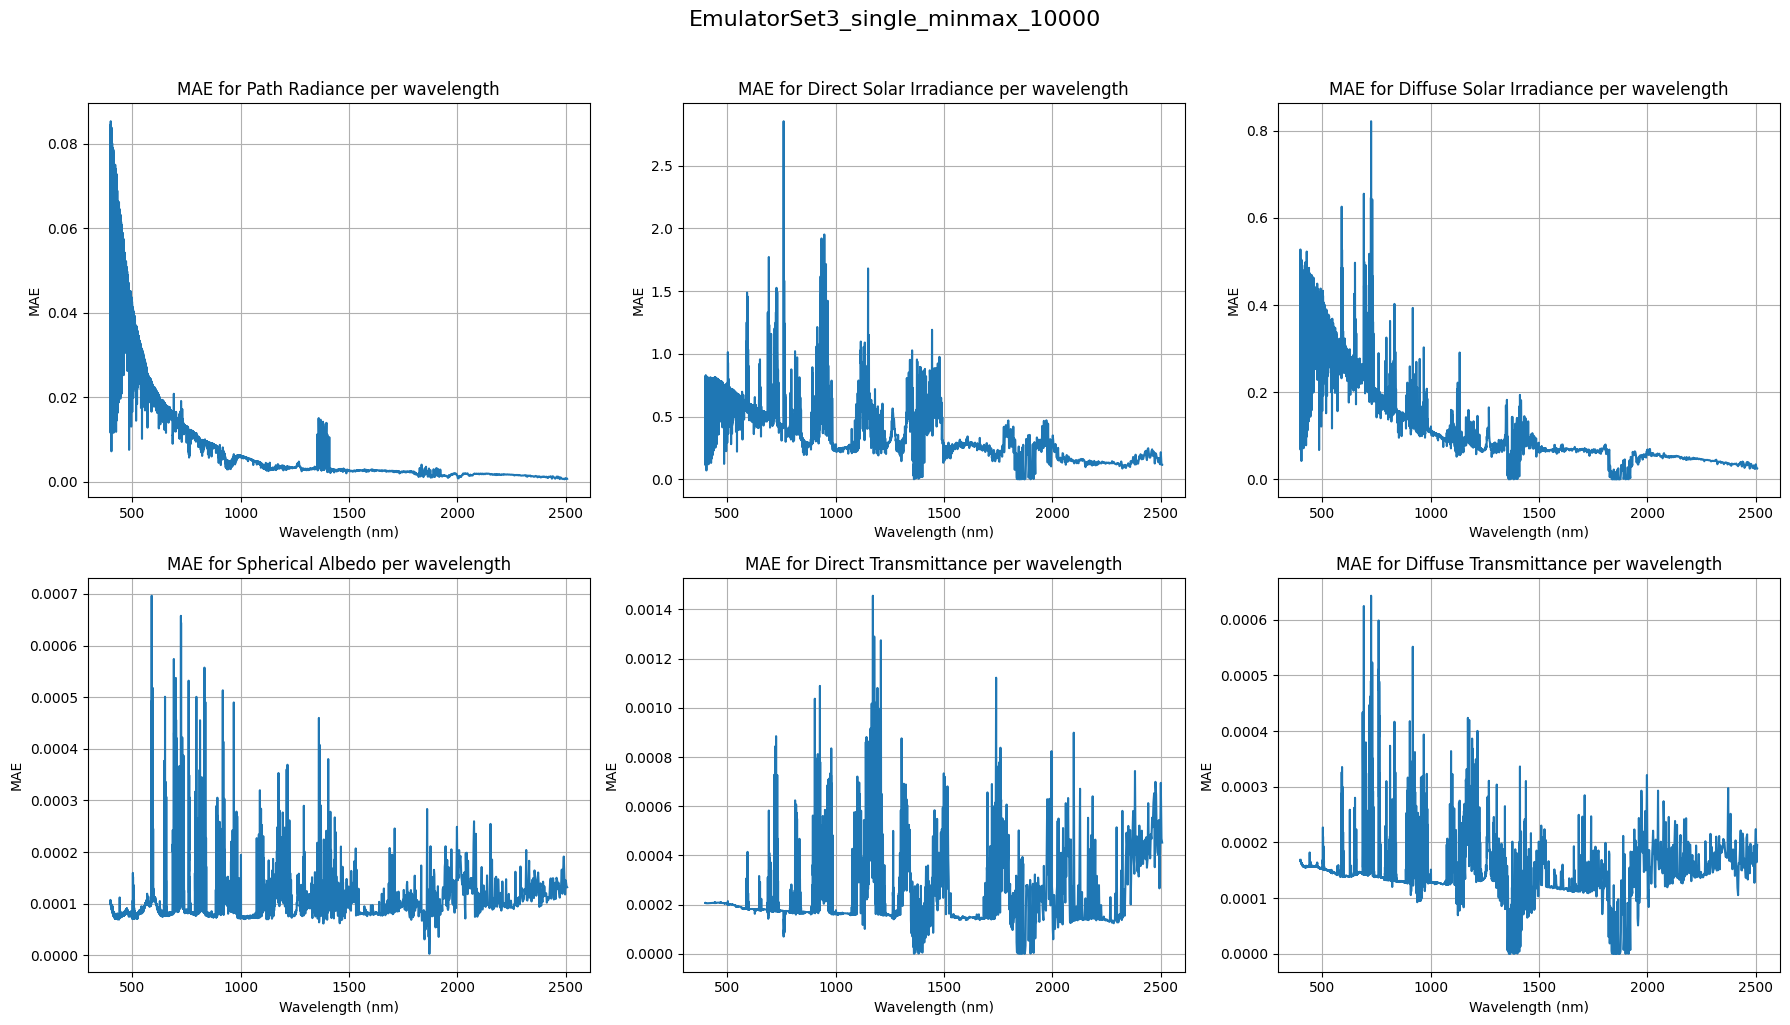

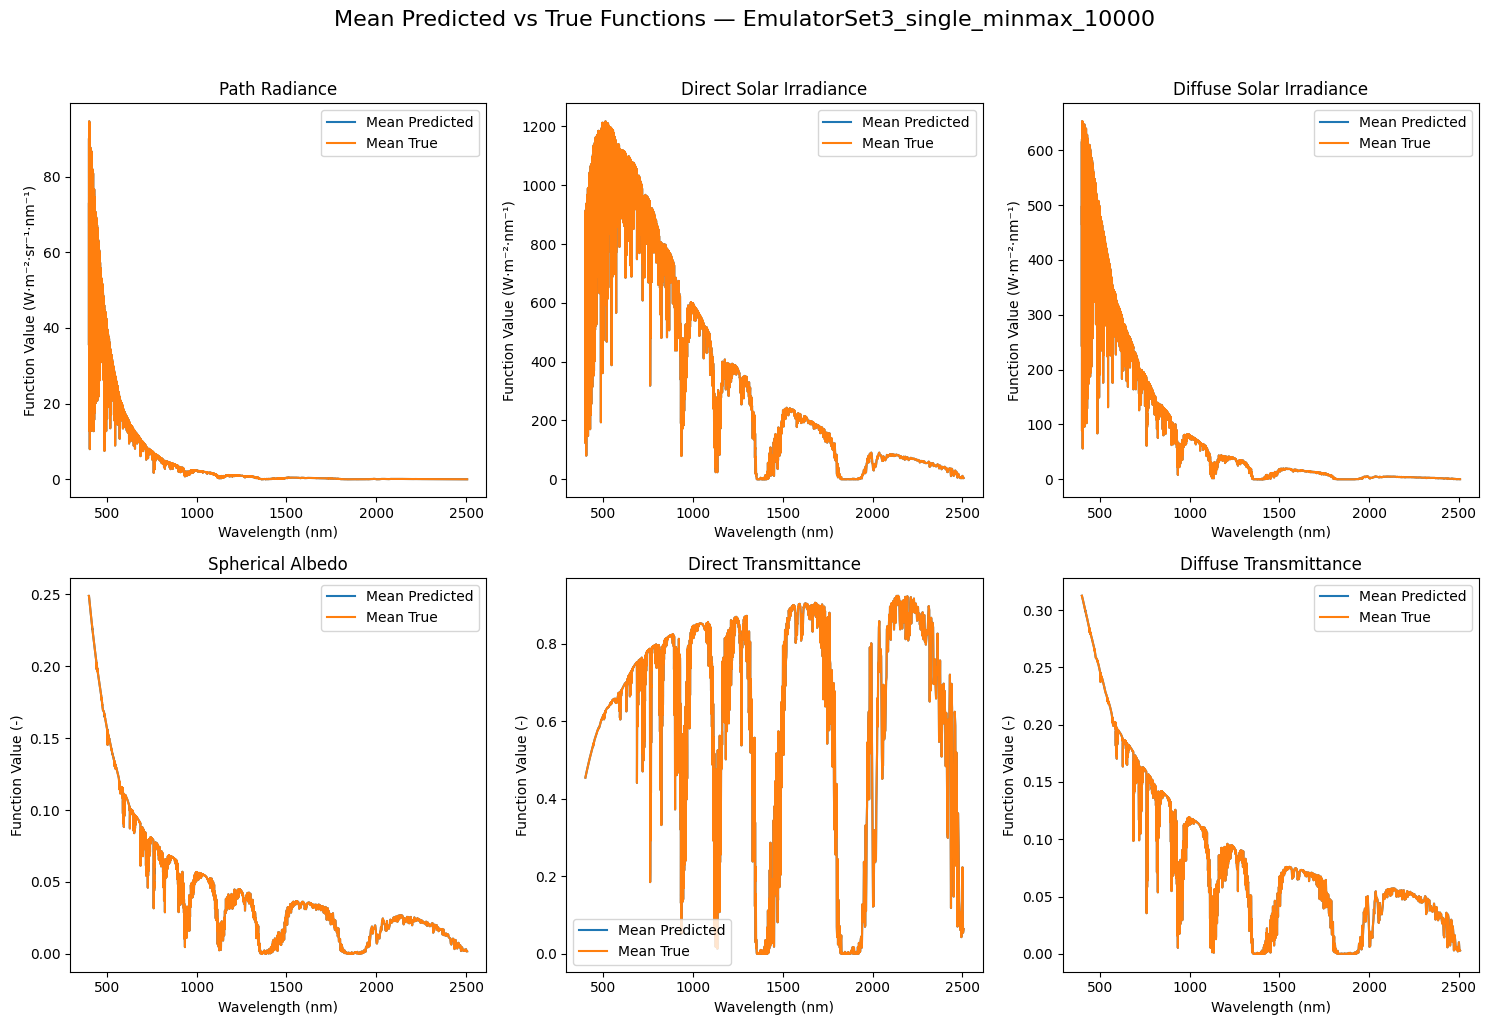

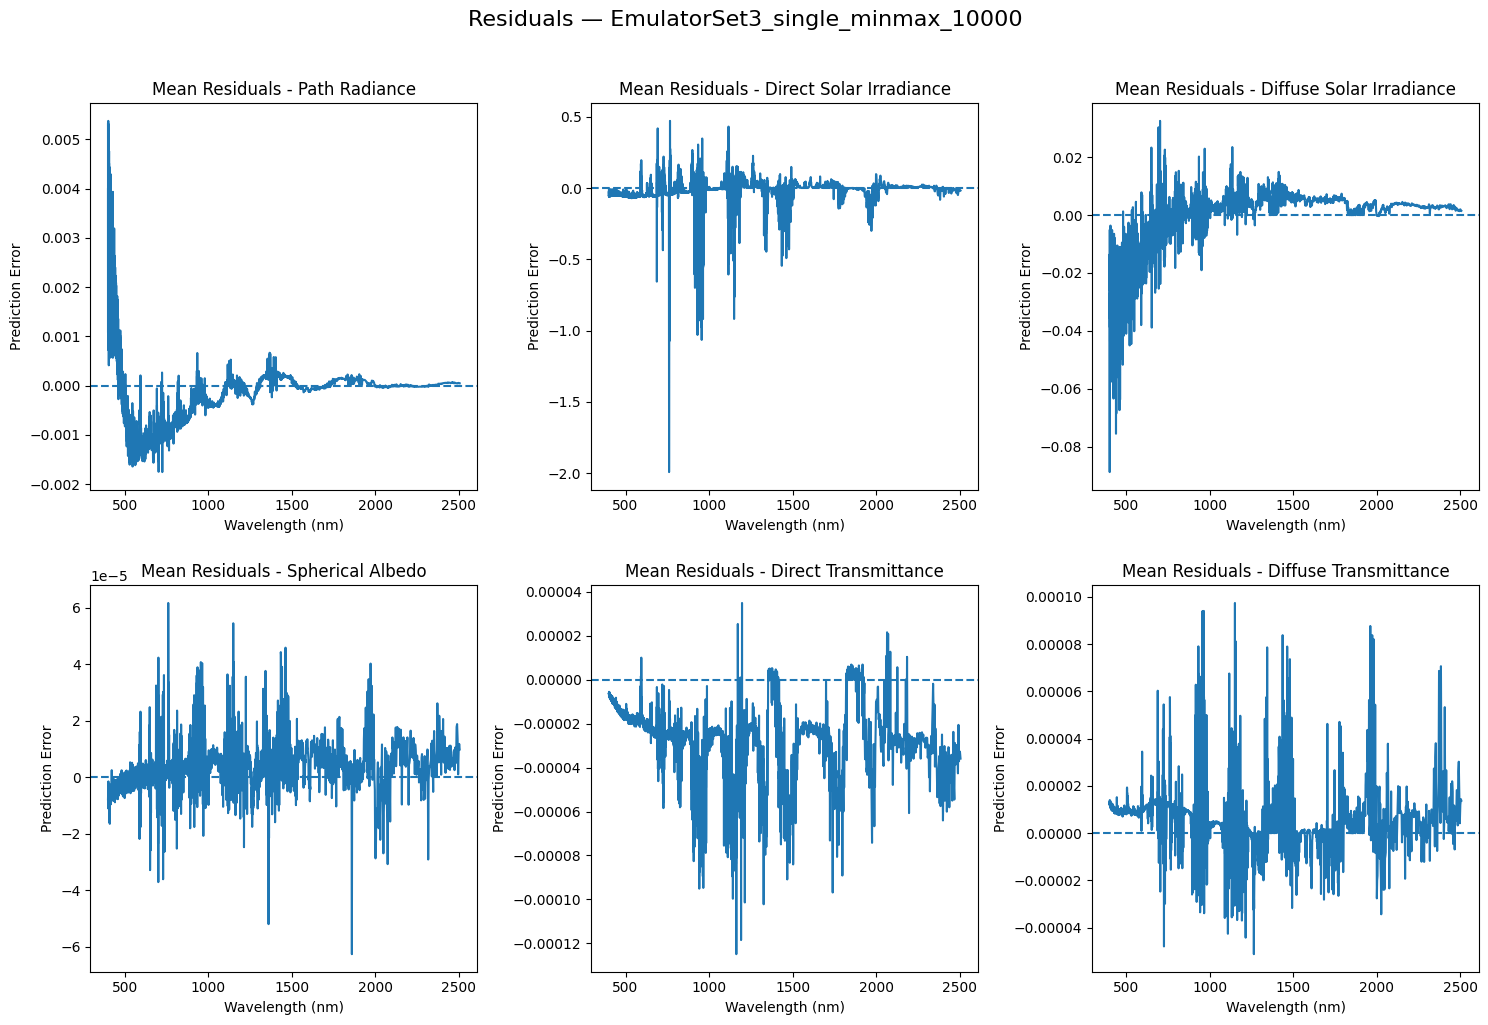

In [45]:
for chosen_model in results_df.sort_values("best_val_mre").itertuples():
    print("--------------------------------------------------")
    print(f"Experiment ID: {chosen_model.experiment_id}")
    print(f"Model: {chosen_model.model}")
    print(f"Encoder: {chosen_model.encoder}")
    print(f"Scale Type: {chosen_model.scale_type}")
    print(f"Dataset Size: {chosen_model.dataset_size}")
    print(f"Fit Time: {chosen_model.fit_time:.2f} seconds")
    print(f"Best Validation MRE: {chosen_model.best_val_mre:.4f}")
    print(f"Best Validation MAE: {chosen_model.best_val_mae:.4f}")
    print("--------------------------------------------------")
    
    start_time = time.time()
    y_pred_test_np = test_model(chosen_model._asdict())
    end_time = time.time()

    test_mre, test_mre_per_func = utils.show_test_results_mre(Y_test, y_pred_test_np, wavelengths, exp_id=chosen_model.experiment_id, save_path="nn_saves/testing_results/")
    test_mae, test_mae_per_func = utils.show_test_results_mae(Y_test, y_pred_test_np, wavelengths, exp_id=chosen_model.experiment_id, save_path="nn_saves/testing_results/")

    entry = {
        "experiment_id": chosen_model.experiment_id,
        "model": chosen_model.model,
        "encoder": chosen_model.encoder,
        "scale_type": chosen_model.scale_type,
        "dataset_size": chosen_model.dataset_size,
        "inference_time": end_time - start_time,
        "test_mre": test_mre,
        "test_mae": test_mae,
    }

    for name, value in zip(globals.function_names_results, test_mre_per_func):
        entry[f"test_mre_{name}"] = value

    for name, value in zip(globals.function_names_results, test_mae_per_func):
        entry[f"test_mae_{name}"] = value

    results_df = pd.DataFrame([entry])
    results_df.to_csv("./nn_saves/testing_results/nn_test_results.csv", mode="a", header=not Path("./nn_saves/testing_results/nn_test_results.csv").exists(), index=False)

    utils.show_predicted_vs_true(Y_test, y_pred_test_np, None, wavelengths, exp_id=chosen_model.experiment_id, save_path="nn_saves/testing_results/")
    utils.show_residuals(Y_test, y_pred_test_np, wavelengths, exp_id=chosen_model.experiment_id, save_path="nn_saves/testing_results/")
    break

Load the test csv and apply the model to measure inference runtime.

In [ ]:
X_test_csv = utils.load_test_csv(globals.CURRENT_TEST_FILE)
print(f"Test inputs from CSV shape: {X_test_csv.shape}")

is_scaled  = y_scalers is not None
is_reduced = pca_list  is not None
model.eval()

start_time_test_csv = time.time()

# scale test inputs with the same scaler used for training
X_test_csv_scaled = config["x_scalers"][chosen_model["scale_type"]].transform(X_test_csv)

X_test_tensor = torch.tensor(X_test_csv_scaled, dtype=torch.float32).to(device)

with torch.no_grad():
    y_pred_test = model(X_test_tensor)
    if is_scaled or is_reduced:
        y_pred_og_shape = torch.zeros((y_pred_test.size(0), globals.N_FUNCTIONS, len(wavelengths)), device=y_pred_test.device)
        for i in range(globals.N_FUNCTIONS):
            y_pred_restored = y_pred_test[:, i, :].cpu().detach().numpy()
            if is_scaled:
                y_pred_restored = y_scalers[i].inverse_transform(y_pred_restored)
            if is_reduced:
                y_pred_restored = pca_list[i].inverse_transform(y_pred_restored)
            y_pred_og_shape[:, i, :] = torch.from_numpy(y_pred_restored).to(y_pred_test.device)
        y_pred_test = y_pred_og_shape
end_time_test_csv = time.time()

y_pred_test_np = y_pred_test.cpu().numpy()

print(f"Time taken to predict on test CSV: {end_time_test_csv - start_time_test_csv:.2f} seconds")
print("Predictions on test CSV shape:", y_pred_test_np.shape)

Test inputs from CSV shape: (10000, 9)
Time taken to predict on test CSV: 4.29 seconds
Predictions on test CSV shape: (10000, 6, 4205)


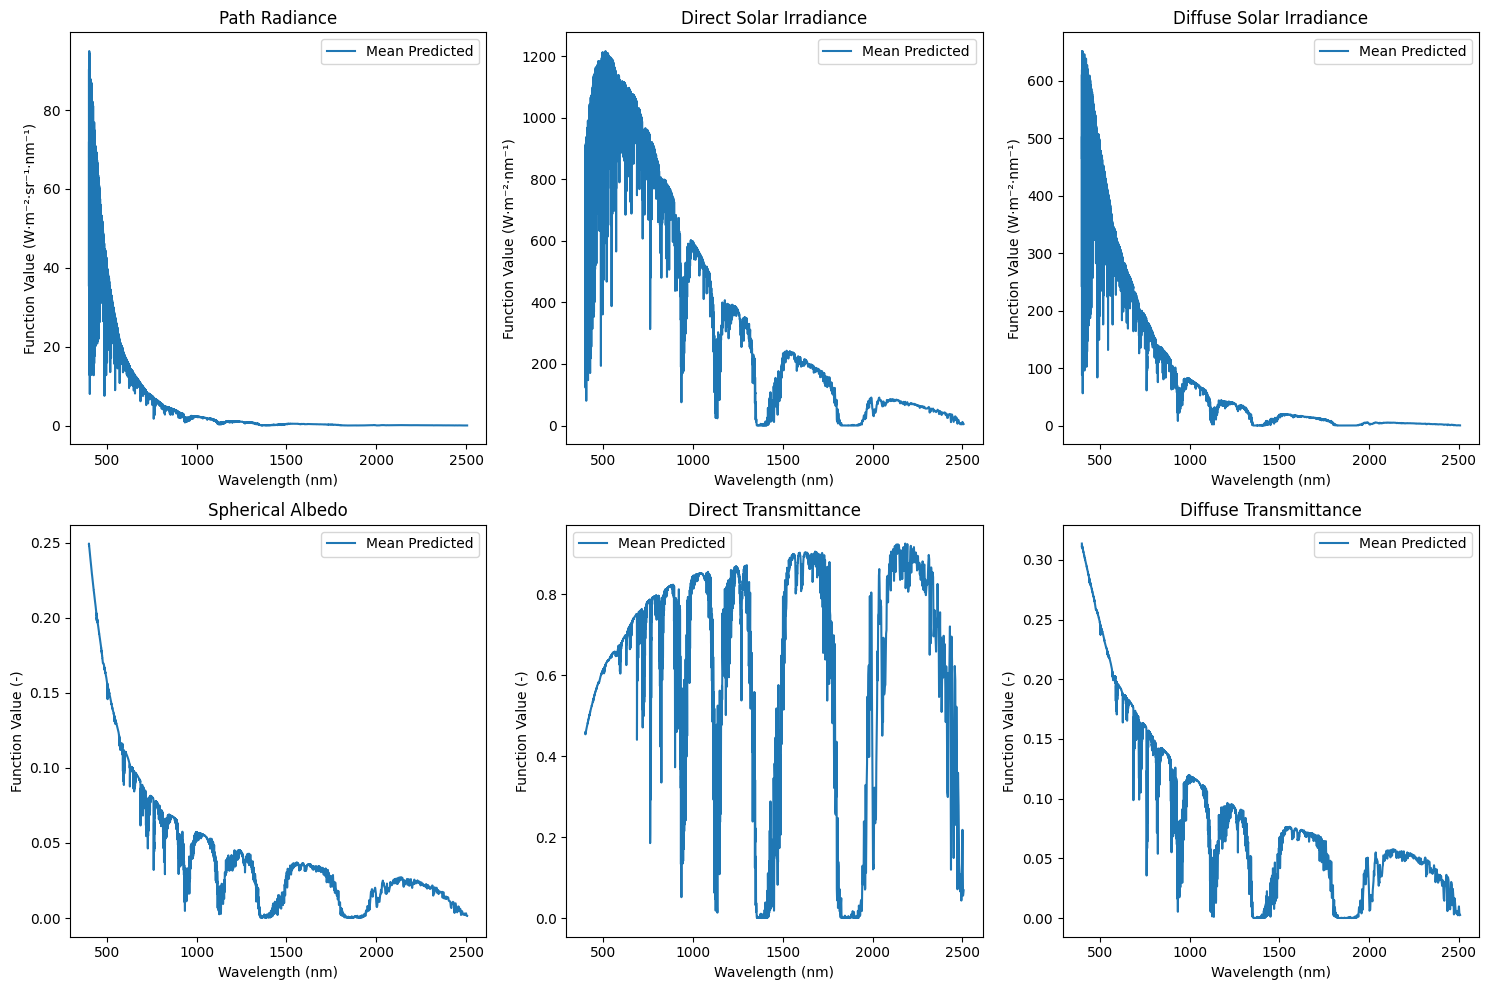

In [19]:
plt.figure(figsize=(15, 10))
for i in range(globals.N_FUNCTIONS):  # iterate over functions
    plt.subplot(2, 3, i + 1)
    plt.plot(wavelengths, np.mean(y_pred_test_np[:, i, :], axis=0), label="Mean Predicted")
    plt.title(f"{globals.function_names_plots[i]}")
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Function Value (" + globals.function_units_plots[i] + ")")
    plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# for f_tuple, func_name in zip(features, globals.function_names_plots):
#     items = [(name, f) for name, f in f_tuple.items() if name != '32']

#     fig, axes = plt.subplots(2, 3, figsize=(15, 6))
#     axes = axes.ravel()  # flatten to a 1D array

#     for ax, (name, f) in zip(axes, items):
#         # average channels into one spectrum
#         y = f[0].mean(0).cpu().numpy()

#         ax.plot(y)
#         ax.set_title(name)
#         ax.grid(True)

#     # hide any unused subplots (in case there are fewer than 6)
#     for ax in axes[len(items):]:
#         ax.set_visible(False)

#     plt.suptitle(func_name)
#     plt.tight_layout()
#     plt.show()